# Gaussian Process Regression: Airline Passengers Data Set

First 5 records of the cleaned data:
   Chl_a      NO2       NO3        NH4        PO4
0   6.66  0.21830  0.522735  31.784807  15.317651
1   6.45  0.21830  0.522735  31.784807  15.317651
2   6.27  0.21830  0.522735  31.784807  15.317651
3   6.13  0.21495  0.527931  30.446107  14.834307
4   6.10  0.21495  0.527931  30.446107  14.834307

Shape of the data after removing missing rows: (109, 5)

Generating pair plot...


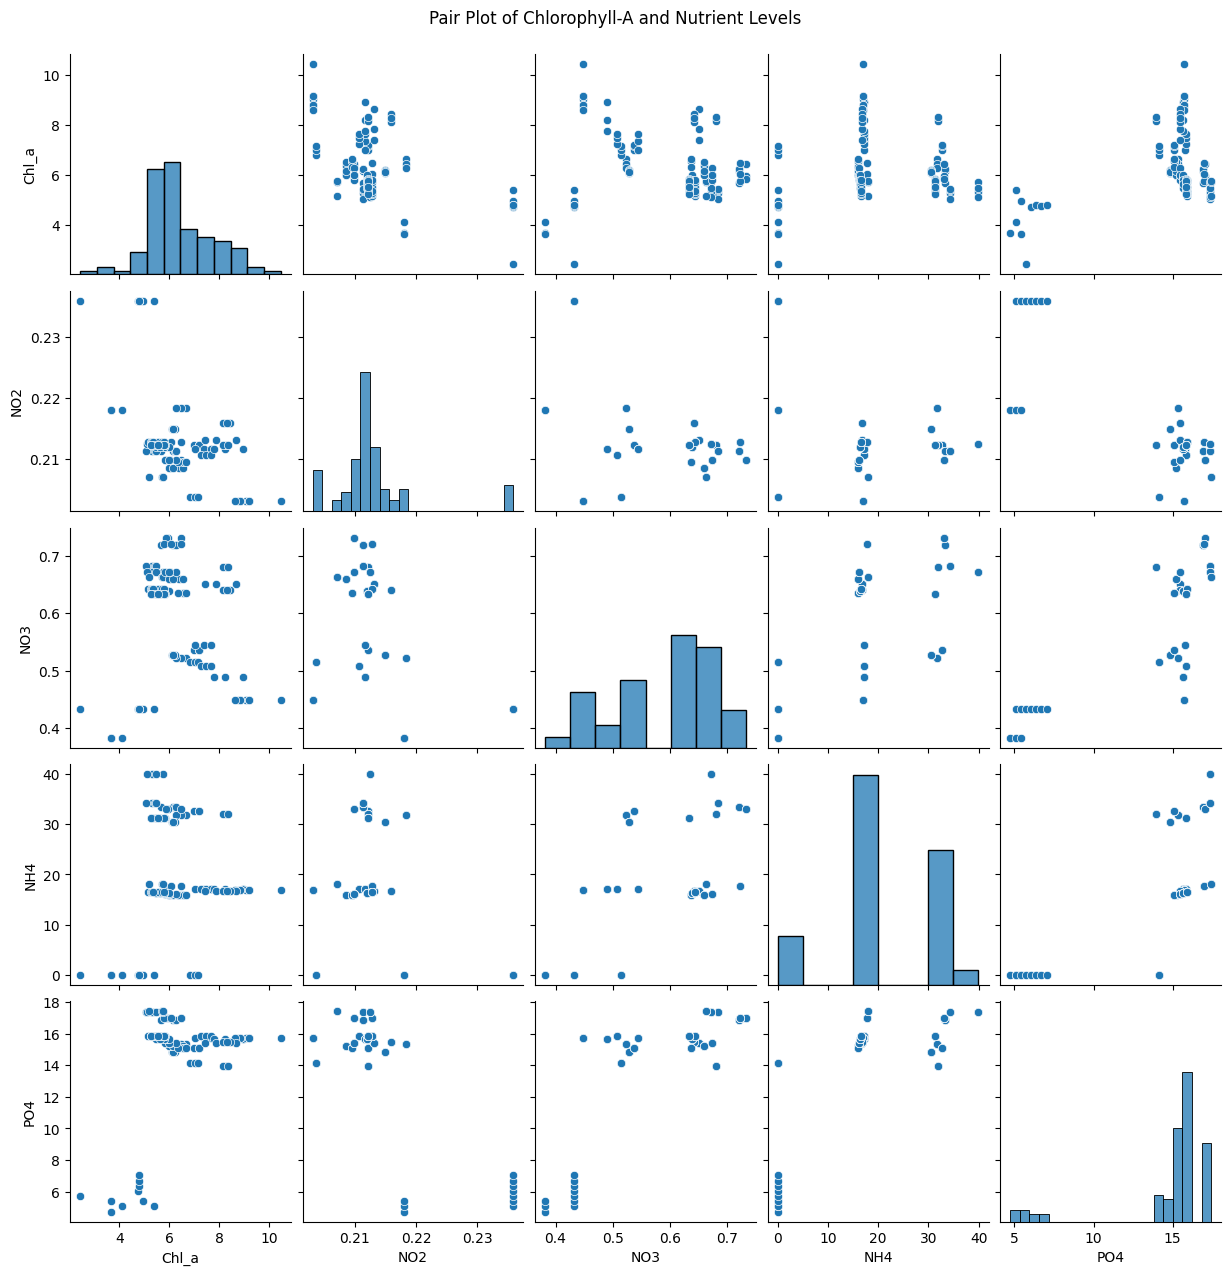


--- Gaussian Process Regressor (GPR) Results ---
HIGHLIGHTED ANSWER: The RMSE on the Test Set is: 0.6508


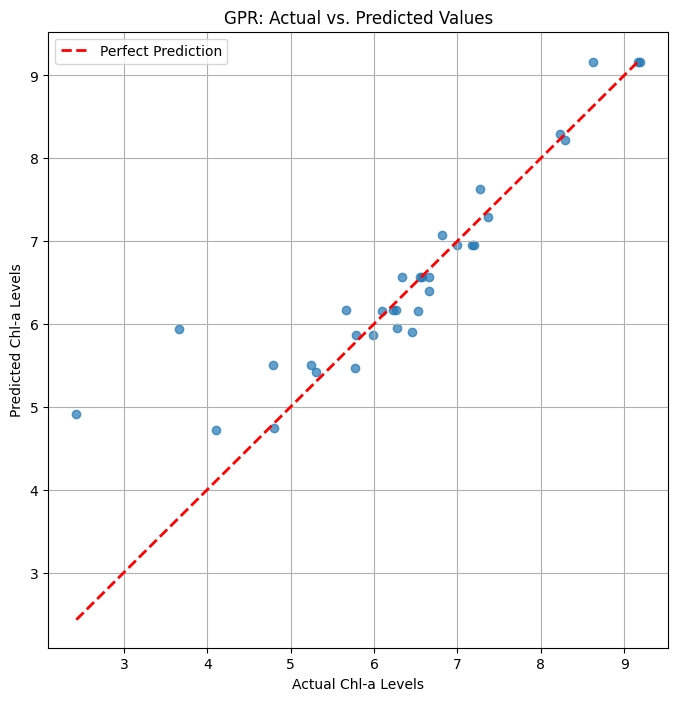


--- Kernel Ridge Regression (KRR) Results ---
HIGHLIGHTED ANSWER: The RMSE on the Test Set is: 0.9966


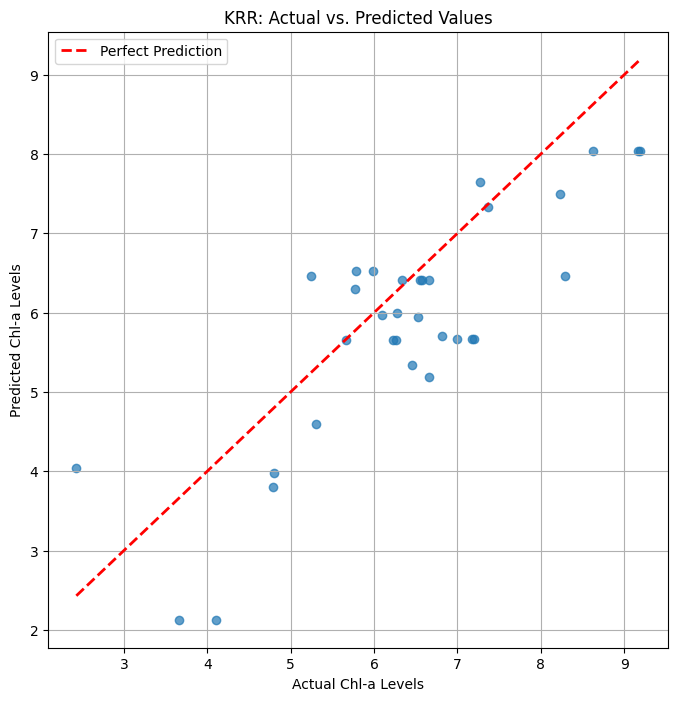


--- Model Comparison ---
GPR Test RMSE: 0.6508
KRR Test RMSE: 0.9966

In terms of accuracy: GPR performed better or tie


In [9]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.kernel_ridge import KernelRidge

# Load data
df = pd.read_csv("https://raw.githubusercontent.com/kspilario/predict_chlorophyll/main/chlor.csv")
df = df.iloc[:, [0, 2, 3, 4, 5]]
df.columns = ['Chl_a', 'NO2', 'NO3', 'NH4', 'PO4']
df_cleaned = df.dropna()

print("First 5 records of the cleaned data:")
print(df_cleaned.head())
print(f"\nShape of the data after removing missing rows: {df_cleaned.shape}")

# Pair plot
print("\nGenerating pair plot...")
sns.pairplot(df_cleaned, diag_kind="hist")
plt.suptitle('Pair Plot of Chlorophyll-A and Nutrient Levels', y=1.02)
plt.show()

# Features/target
X = df_cleaned[['NO2', 'NO3', 'NH4', 'PO4']]
y = df_cleaned['Chl_a']

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# ---------- (b) GPR ----------
kernel = (
    C(1.0, (1e-3, 1e3)) *
    RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e3))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-6, 1e1))
)

GPR = make_pipeline(
    StandardScaler(),
    GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.0,                 # noise handled by WhiteKernel
        normalize_y=True,
        random_state=42,
        n_restarts_optimizer=2
    )
)

GPR.fit(X_train, y_train)
y_pred_gpr = GPR.predict(X_test)
rmse_gpr = np.sqrt(mean_squared_error(y_test, y_pred_gpr))

print("\n--- Gaussian Process Regressor (GPR) Results ---")
print(f"HIGHLIGHTED ANSWER: The RMSE on the Test Set is: {rmse_gpr:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_gpr, alpha=0.7)  # drop edgecolors to avoid warnings
lo, hi = y_test.min(), y_test.max()
plt.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Chl-a Levels")
plt.ylabel("Predicted Chl-a Levels")
plt.title("GPR: Actual vs. Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

# ---------- (c) KRR ----------
# Option A (keep your linear kernel):
# krr_model = KernelRidge(kernel='linear', alpha=1.0)

# Option B (try a real kernelized version as well):
KRR = make_pipeline(
    StandardScaler(),
    KernelRidge(kernel="rbf", alpha=1.0, gamma=None)
)

KRR.fit(X_train, y_train)
y_pred_krr = KRR.predict(X_test)
rmse_krr = np.sqrt(mean_squared_error(y_test, y_pred_krr))

print("\n--- Kernel Ridge Regression (KRR) Results ---")
print(f"HIGHLIGHTED ANSWER: The RMSE on the Test Set is: {rmse_krr:.4f}")

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_krr, alpha=0.7)
lo, hi = y_test.min(), y_test.max()
plt.plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Chl-a Levels")
plt.ylabel("Predicted Chl-a Levels")
plt.title("KRR: Actual vs. Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

# --- HIGHLIGHTED ANSWER: Model Comparison ---
print("\n--- Model Comparison ---")
print(f"GPR Test RMSE: {rmse_gpr:.4f}")
print(f"KRR Test RMSE: {rmse_krr:.4f}")
print("\nIn terms of accuracy:", "KRR performed better (lower RMSE)" if rmse_krr < rmse_gpr else "GPR performed better or tie")
